In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from MDAnalysis.lib.distances import distance_array
from sklearn.preprocessing import normalize

In [2]:
u = mda.Universe("6N3C+POPC.gro","6N3C+POPC.xtc")
protein = "protein"
lipid = "resname POPC"
lipid_atoms = u.select_atoms(lipid)
total_lipids = len(lipid_atoms.residues)
protein_atoms = u.select_atoms(protein)
n_residues = len(protein_atoms.residues)

residues = []
timesteps = []
for i, ts in enumerate(u.trajectory[::10]):
    timesteps.append(i)

for l in protein_atoms.residues.resids:
    residues.append(l)
    
n_frames = len(timesteps)

contact_matrix_POPC = np.zeros([n_frames, n_residues])

for i, ts in enumerate(u.trajectory[::10]):
    for j, residue in enumerate(protein_atoms.residues):
        ca_atom = residue.atoms.select_atoms("name CA")
        distances = np.linalg.norm(lipid_atoms.positions - ca_atom.positions, axis=1)
        lipid_resids_within_cutoff = np.where(distances <= 10.0)[0]
        corresponding_lipid_resids = set([lipid_atoms[resid_index].resid for resid_index in lipid_resids_within_cutoff])
        num_lipids_within_cutoff = len(corresponding_lipid_resids)
        contact_matrix_POPC[i, j] = num_lipids_within_cutoff
        
normalized_contact_matrix_POPC = (contact_matrix_POPC - contact_matrix_POPC.min()) / (contact_matrix_POPC.max() - contact_matrix_POPC.min())    

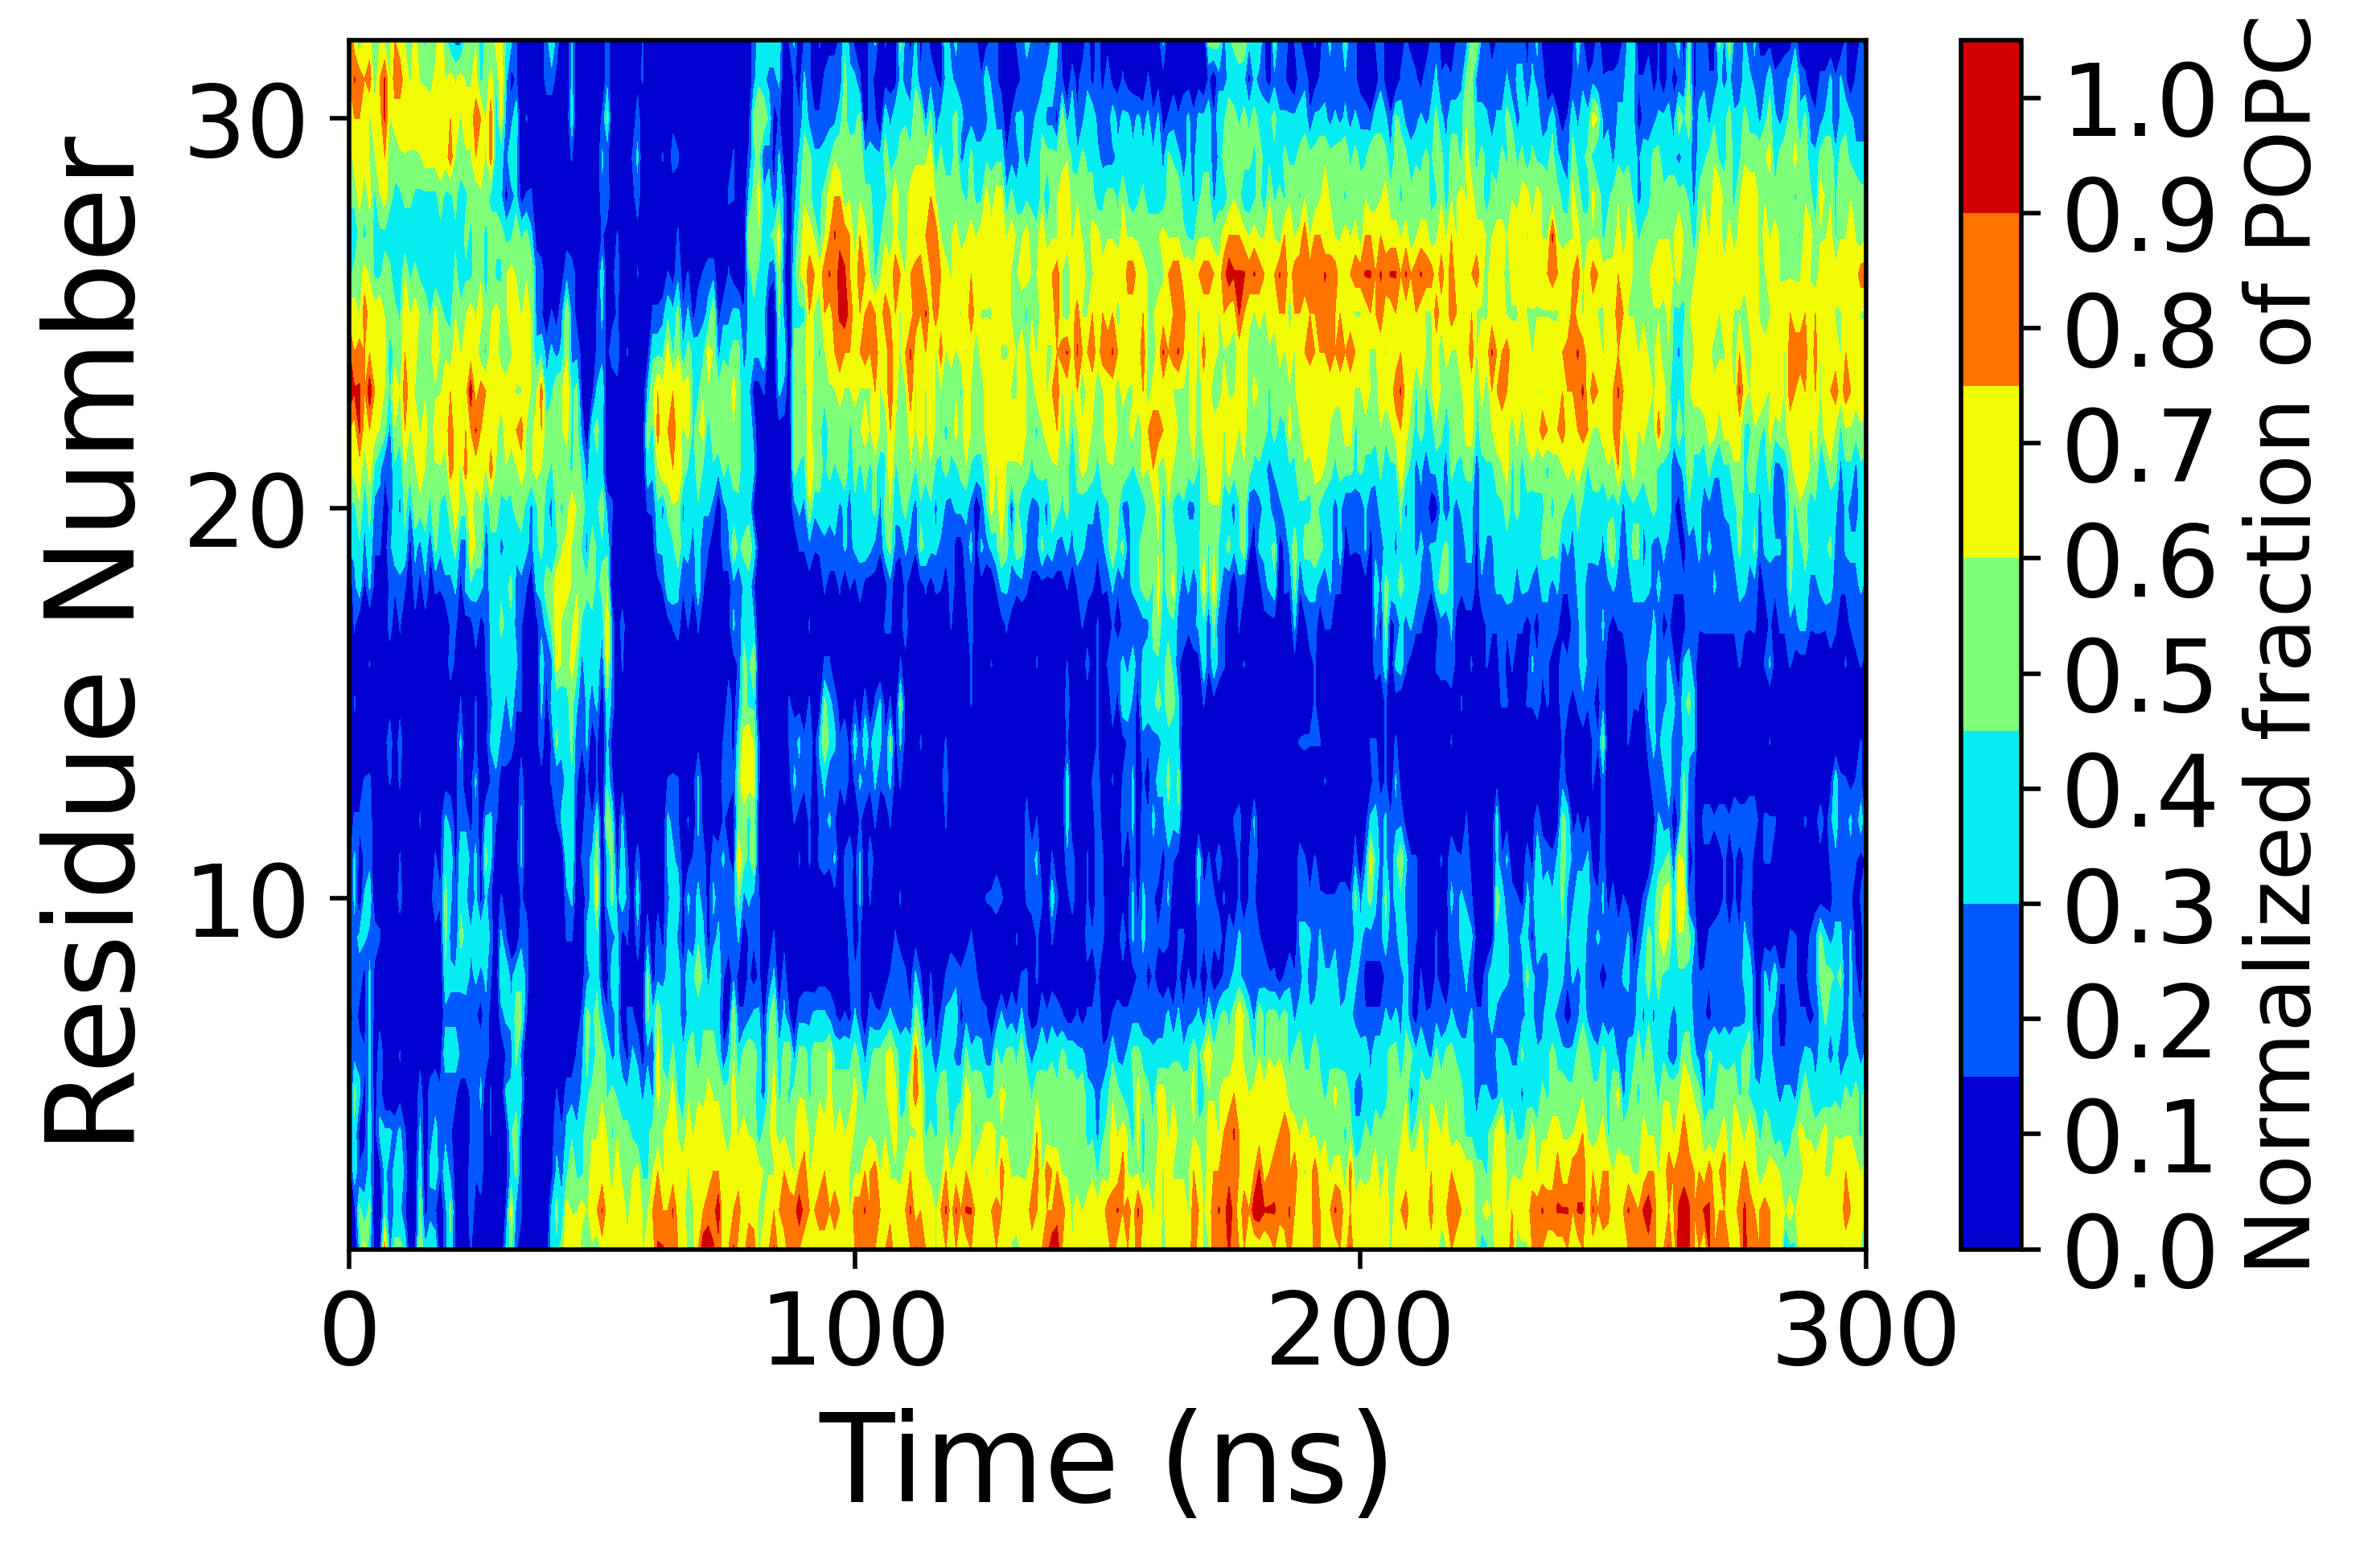

In [3]:
norm = cm.colors.Normalize(vmax=abs(normalized_contact_matrix_POPC).max(), vmin= abs(normalized_contact_matrix_POPC).min())

plt.figure(dpi=500)
contourf = plt.contourf(timesteps, residues, normalized_contact_matrix_POPC.T,cmap='jet')  
colorbar = plt.colorbar(contourf,ticks=np.arange(0, 1.1, 0.1),spacing='proportional')
colorbar.set_label('Normalized fraction of POPC',fontsize=16)
colorbar.ax.tick_params(labelsize=18)
plt.xlabel('Time (ns)', fontsize=22)
plt.ylabel('Residue Number', fontsize=22)
plt.tick_params(axis = "both",which = "major",labelsize=18)
plt.tight_layout()
plt.savefig("6N3C+POPC_contourf_normalize.png",dpi=500)
plt.show()